In [2]:
#Replicating figures from Grillot fog article

import numpy as np
import matplotlib.pyplot as plt
import miepython as mie
from scipy.special import erfc
import scattering_funcs as sf
import noise_impact_funcs as nf
import pandas as pd

In [ ]:
#Load refractive index data.
#Segelstein data for water, wavelength in µm. [wavelength, n, k], where complex refractive index is m = n + ik.
ref_index_data = np.loadtxt(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\H20_Segelstein.txt", skiprows=13, delimiter=None,comments="#")

#Verify the data looks correct
# plt.plot(ref_index_data[:,0], ref_index_data[:,1], label="n")
# plt.plot(ref_index_data[:,0], ref_index_data[:,2], label="k")
# plt.xscale("log")
# plt.grid()
# plt.ylim(0,10)


#Truncate to match Grillot paper
i_start = np.min(np.where(ref_index_data[:,0] >= 0.1)) #0.1µm wavelength start
i_end = np.max(np.where(ref_index_data[:,0] <= 20)) #20µm wavelength end

ref_index_data_trunc = ref_index_data[i_start:i_end]

wavelengths = ref_index_data_trunc[:,0]
n_values = ref_index_data_trunc[:,1]
k_values = ref_index_data_trunc[:,2]

m = n_values + 1j * k_values #complex refractive index used for Mie scattering



In [ ]:
#Calculate the Mie scattering cross-sections (coefficients) for a range of droplet sizes (used in Grillot paper) and wavelengths from 0.1µm to 20µm spacing from Segelstein data.

radius = np.linspace(0.01, 50, 1000)  # in microns

geometric_cross_section = np.pi * radius**2

q_ext = [0]*len(wavelengths)
q_sca = q_ext.copy()
q_abs = q_ext.copy()
q_back = q_ext.copy()
g = q_ext.copy()

for i,lambda0 in enumerate(wavelengths):
   
    q_ext[i], q_sca[i], q_back[i], g[i] = mie.efficiencies(m[i], 2 * radius, lambda0)
    q_abs[i] = q_ext[i] - q_sca[i]



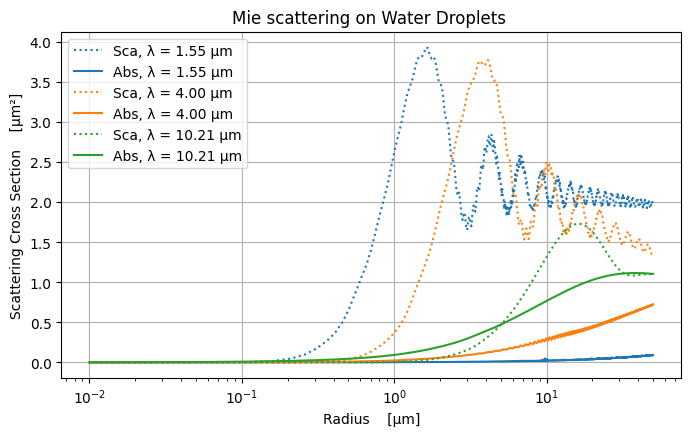

In [5]:
#Plot Mie scattering cross-section (coefficients) for 1.55µm, 4µm and 10µm wavelengths as a function of droplet radius.

plt.figure(figsize=(8, 4.5))

i_1550 =np.max(np.where(wavelengths <= 1.55))
i_4000 =np.max(np.where(wavelengths <= 4))
i_10000 =np.min(np.where(wavelengths >= 10.2))

wav_FSO_index = [i_1550, i_4000, i_10000]

for i in wav_FSO_index:
    line = plt.plot(radius, q_sca[i], label=f"Sca, λ = {wavelengths[i]:.2f} µm",linestyle='dotted')
    plt.plot(radius, q_abs[i], label=f"Abs, λ = {wavelengths[i]:.2f} µm",color=line[0].get_color())

plt.title("Mie scattering on Water Droplets ")
plt.xlabel("Radius    [µm]")
plt.ylabel("Scattering Cross Section    [µm²]")
plt.xscale("log")
plt.legend()
plt.grid()

plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\Mie_scattering_on_water.svg")
plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\Mie_scattering_on_water.pdf")


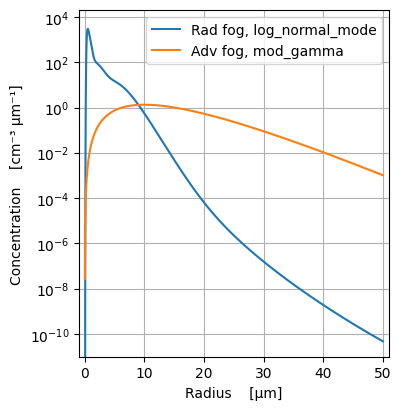

In [ ]:
fog_data = sf.load_fog_data(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Radiation_fog_data.xlsx")

fog14 = fog_data[13]

dist_rad = sf.log_normal_modes(fog14["N_k"], fog14["sigma_k"], fog14["r_k"],radius)

alpha = 3
a = 0.027
b = 0.3

dist_adv = sf.mod_gamma_dist(a,b,alpha,radius)


plt.figure(figsize=(4, 4.5))

plt.yscale("log")
plt.yticks([10**i for i in range(-10, 5, 2)])
plt.ylim(1e-11,2e4)
plt.xlim(-1,51)
plt.grid(which="major")
plt.xlabel("Radius    [µm]")
plt.ylabel("Concentration    [cm⁻³ µm⁻¹]")
plt.plot(radius,dist_rad,label='Rad fog, log_normal_mode')
plt.plot(radius,dist_adv,label='Adv fog, mod_gamma')
plt.legend()

plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\Fog_DSDs.svg")
plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\Fog_DSDs.pdf")


                            1.55 µm    4.00 µm   10.21 µm
Radiation fog extinction  24.535033  23.227028   7.971897
Radiation fog scattering  24.432031  21.956028   4.085723
Radiation fog absorption   0.103002   1.271001   3.886174
Advection fog extinction  29.499014  31.056174  33.828827
Advection fog scattering  28.938157  25.085258  20.245225
Advection fog absorption   0.560856   5.970916  13.583603


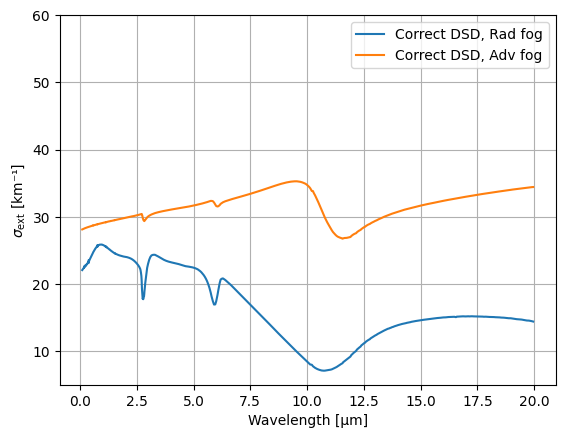

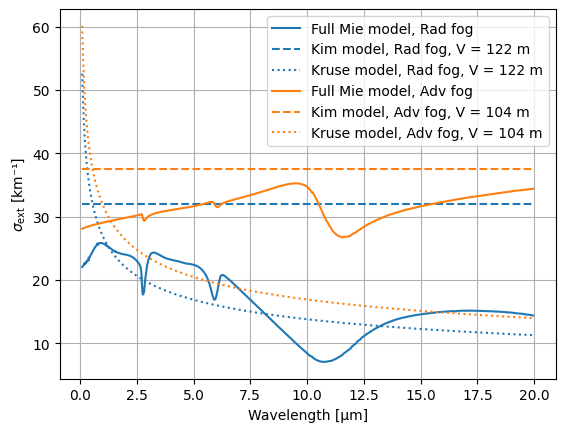

In [7]:
#Calculate and plot the Mie extinction coefficients using the reconstructed DSDs. Essentially integrating over DSD times pi*r^2*Q_k, where Q_k is the Mie efficiency for extinction, scattering or absorption.
#We compare with the Kim and Kruse visibility models, using visibility values from the Grillot paper (122 m for radiation fog and 104 m for advection fog).


decimals = 2
lambda0s = wavelengths[wav_FSO_index]
lambda0_labels = [f"{wl:.{decimals}f} µm" for wl in lambda0s]

dsd_map = {"Radiation fog": dist_rad, "Advection fog": dist_adv}
eff_map = {"extinction": q_ext, "scattering": q_sca, "absorption": q_abs}

coefficients = {}
for dsd_label, dsd in dsd_map.items():
    for eff_label, q_values in eff_map.items(): #For each Mie cross-section, Q_k (which is a list of 755 wavelength input and inside has 1000 radius input)
        row_label = f"{dsd_label} {eff_label}"
        
        #For each wavelength, DSD type and Q_k[wavelength], calculate the extinction value by integrating over radii:
        coefficients[row_label] = [
            sf.mie_extinction_coefficient(dsd, q_values[i], radius) #For the DSD type, we calculate a list of extinction coefficients (attenuation) for each Mie cross section list (at the specific wavelength) which corresponds to the extinction value for the wavelength. Where we have integrated over all radii values to obtain the final extinction coefficient for each wavelength. 
            for i in range(len(wavelengths)) #So we get a list for each row label. We have an extinction value for each of the 755 wavelengths we look at. 
        ]

df = pd.DataFrame(coefficients, index=[f"{wl:.{decimals}f} µm" for wl in wavelengths]).T
print(df[lambda0_labels])

rad_ext_string = "Radiation fog extinction"
rad_sca_string = "Radiation fog scattering"
rad_abs_string = "Radiation fog absorption"

adv_ext_string = "Advection fog extinction"
adv_sca_string = "Advection fog scattering"
adv_abs_string = "Advection fog absorption"

rad_ext = df.loc[rad_ext_string].values
rad_sca = df.loc[rad_sca_string].values
rad_abs = df.loc[rad_abs_string].values

adv_ext = df.loc[adv_ext_string].values
adv_sca = df.loc[adv_sca_string].values
adv_abs = df.loc[adv_abs_string].values



plt.figure()
line1 = plt.plot(wavelengths, rad_ext, label='Correct DSD, Rad fog')
line2 = plt.plot(wavelengths, adv_ext, label='Correct DSD, Adv fog')

plt.grid()
plt.legend()
plt.xlabel("Wavelength [µm]")
plt.ylabel(r"$\sigma_\mathrm{ext}$ [km⁻¹]")
plt.ylim(5,60)
plt.legend()

plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\Extinction_coefficient_Mie_rec_vs_correct.svg")
plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\Extinction_coefficient_Mie_rec_vs_correct.pdf")


V_rad = 0.122 #km
V_adv = 0.104 #km

Kim_attenuation_rad = sf.Kim_visibility_model(V_rad, wavelengths)
Kim_attenuation_adv = sf.Kim_visibility_model(V_adv, wavelengths)

Kruse_attenuation_rad = sf.Kruse_visibility_model(V_rad, wavelengths)
Kruse_attenuation_adv = sf.Kruse_visibility_model(V_adv, wavelengths)

plt.figure()

line1 = plt.plot(wavelengths, rad_ext, label='Full Mie model, Rad fog', )
plt.plot(wavelengths, Kim_attenuation_rad, label="Kim model, Rad fog, V = 122 m",linestyle='dashed', color=line1[0].get_color())
plt.plot(wavelengths, Kruse_attenuation_rad, label="Kruse model, Rad fog, V = 122 m",linestyle='dotted', color=line1[0].get_color())

line2 = plt.plot(wavelengths, adv_ext, label='Full Mie model, Adv fog')
plt.plot(wavelengths, Kim_attenuation_adv, label="Kim model, Adv fog, V = 104 m",linestyle='dashed', color=line2[0].get_color())
plt.plot(wavelengths, Kruse_attenuation_adv, label="Kruse model, Adv fog, V = 104 m",linestyle='dotted', color=line2[0].get_color())

plt.grid()
plt.legend()
plt.xlabel("Wavelength [µm]")
plt.ylabel(r"$\sigma_\mathrm{ext}$ [km⁻¹]")
plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\Extinction_coefficient_comparison.svg")
plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\Extinction_coefficient_comparison.pdf")



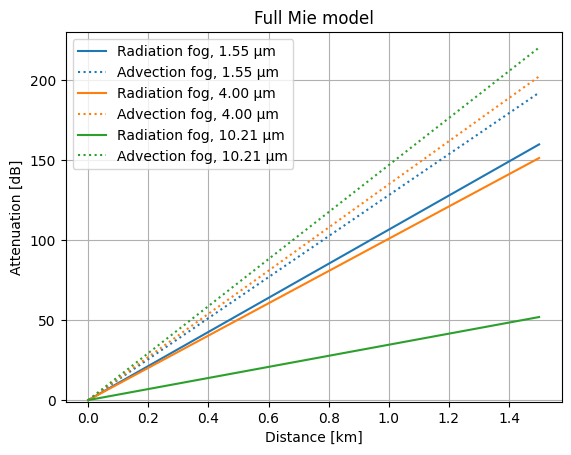

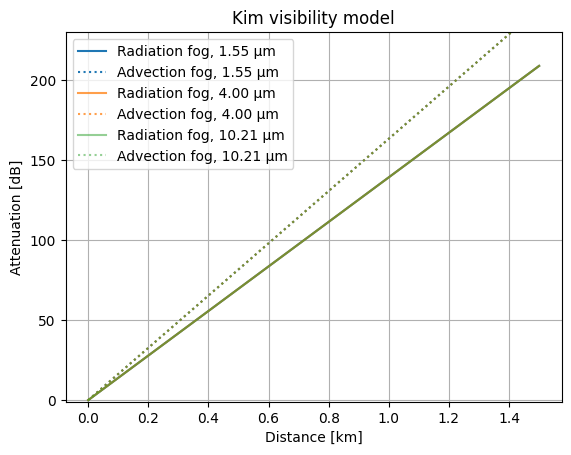

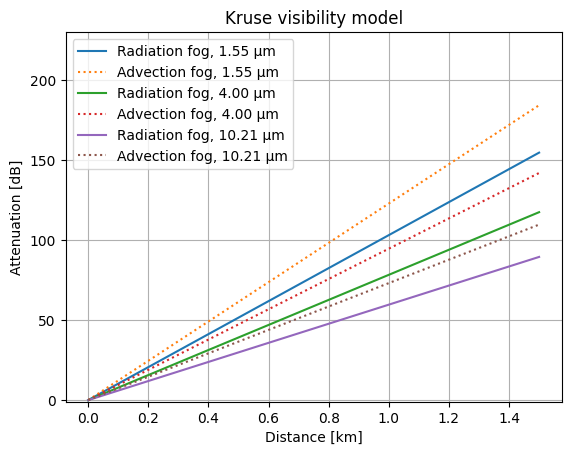

In [8]:
distance = np.linspace(0, 1.5, 1000) #km

power_input = 1 #mW

power_rad_ext = [0]*len(wavelengths)
power_adv_ext = power_rad_ext.copy()

power_rad_ext_Kim = power_rad_ext.copy()
power_adv_ext_Kim = power_rad_ext.copy()

power_rad_ext_Kruse = power_rad_ext.copy()
power_adv_ext_Kruse = power_rad_ext.copy()

for i in range(len(wavelengths)):
    power_rad_ext[i] = sf.Beers_law(power_input, rad_ext[i], distance)[1] #output is att, att_dB, so [1] is result in dB
    power_adv_ext[i] = sf.Beers_law(power_input, adv_ext[i], distance)[1]

    power_rad_ext_Kim[i] = sf.Beers_law(power_input, Kim_attenuation_rad[i], distance)[1]
    power_adv_ext_Kim[i] = sf.Beers_law(power_input, Kim_attenuation_adv[i], distance)[1]

    power_rad_ext_Kruse[i] = sf.Beers_law(power_input, Kruse_attenuation_rad[i], distance)[1]
    power_adv_ext_Kruse[i] = sf.Beers_law(power_input, Kruse_attenuation_adv[i], distance)[1]

counter = 0
for wav_index in wav_FSO_index:

    plt.figure(0)
    line = plt.plot(distance, -power_rad_ext[wav_index], label=f"Radiation fog, {wavelengths[wav_index]:.2f} µm")
    plt.plot(distance, -power_adv_ext[wav_index], label=f"Advection fog, {wavelengths[wav_index]:.2f} µm", linestyle='dotted', color=line[0].get_color())


    plt.figure(1)
    line = plt.plot(distance, -power_rad_ext_Kim[wav_index], label=f"Radiation fog, {wavelengths[wav_index]:.2f} µm", alpha=1-counter/4)
    plt.plot(distance, -power_adv_ext_Kim[wav_index], label=f"Advection fog, {wavelengths[wav_index]:.2f} µm", linestyle='dotted', color=line[0].get_color(),alpha=1-counter/4)


    plt.figure(2)
    line = plt.plot(distance, -power_rad_ext_Kruse[wav_index], label=f"Radiation fog, {wavelengths[wav_index]:.2f} µm")
    plt.plot(distance, -power_adv_ext_Kruse[wav_index], label=f"Advection fog, {wavelengths[wav_index]:.2f} µm", linestyle='dotted')

    counter+=1

models = ["Full Mie model", "Kim visibility model", "Kruse visibility model"]

for i in range(len(lambda0s)):
    plt.figure(i)
    plt.grid()
    plt.legend()
    plt.xlabel("Distance [km]")
    plt.ylabel("Attenuation [dB]")
    plt.ylim(-1,230)
    plt.title(f'{models[i]}')

    plt.savefig(rf"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\Attenuation_{models[i]}.svg")
    plt.savefig(rf"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\Attenuation_{models[i]}.pdf")



In [9]:
# geometric_cross_section_µm2 =  np.pi * radius**2

# # Calculate the extinction cross section in µm²
# for index in wav_FSO_index:
#     Q_k = q_ext[index]
#     extinction_cross_section_µm2 = Q_k * geometric_cross_section_µm2
#     plt.plot(radius,extinction_cross_section_µm2 * DSD_rad,label=index)

#     # Calculate the extinction coefficient in km⁻¹
#     extinction_coefficient_km1 = np.trapezoid(extinction_cross_section_µm2 * DSD_rad, radius)*1e-3
#     print(extinction_coefficient_km1)

# plt.legend()


In [10]:
#Use detector noise values from Grillot paper to calculate the impact of atmospheric attenuation to the received signal and the resulting bit error rate.

NEP_SWIR = 16e-12 #W/Hz^0.5
NEP_MWIR = 2.83e-9 #W/Hz^0.5
NEP_LWIR = 2.36e-9 #W/Hz^0.5

NEPs = [NEP_SWIR, NEP_MWIR, NEP_LWIR]

power_input = [0.1, 1, 10] #W

#For OOK at 1Gbit/s the bandwidth corresponds to half, so 500 MHz
bw = 500e6 #Hz

FEC_thres = 3.8e-3 # forward-error correction threshold

noise_dec = [0]*len(NEPs) #Can only do trick with [0]*integer here, since we don't have nested lists
SNR_rad = [[0 for _ in range(len(wavelengths))] for _ in range(len(power_input))] #SNR list for [ power1:[wav0, wav1, ..] , power2:[wav0, wav1, ..], ...], thus we will have a list of SNR values dependent on the distance at each power and wavelength.
SNR_adv = [[0 for _ in range(len(wavelengths))] for _ in range(len(power_input))]

BER_rad = [[0 for _ in range(len(wavelengths))] for _ in range(len(power_input))]
BER_adv = [[0 for _ in range(len(wavelengths))] for _ in range(len(power_input))]

for i,NEP in enumerate(NEPs):
    noise_dec[i] = nf.detector_noise(NEP, bw)


SWIR = (wavelengths >= 1) & (wavelengths <= 2.5)
MWIR = (wavelengths >= 3) & (wavelengths <= 5)
LWIR = (wavelengths >= 8) & (wavelengths <= 12)

for i, power in enumerate(power_input): #Powers
    for j, wavelength in enumerate(wavelengths): # wavelengths

        if SWIR[j]:#check detector to be used
            noise = noise_dec[0] 
        elif MWIR[j]:
            noise = noise_dec[1]
        elif LWIR[j]:
            noise = noise_dec[2]
        else:
            noise = np.inf
        
        attenuation_rad = 10**(power_rad_ext[j]/10) #Convert total attenuation (dependent on distance) from dB to linear
        attenuation_adv = 10**(power_adv_ext[j]/10) 
        
        SNR_rad[i][j] = nf.signal_to_noise_ratio(power, attenuation_rad, noise)
        SNR_adv[i][j] = nf.signal_to_noise_ratio(power, attenuation_adv, noise)

        BER_rad[i][j] = nf.bit_error_rate(SNR_rad[i][j])
        BER_adv[i][j] = nf.bit_error_rate(SNR_adv[i][j])



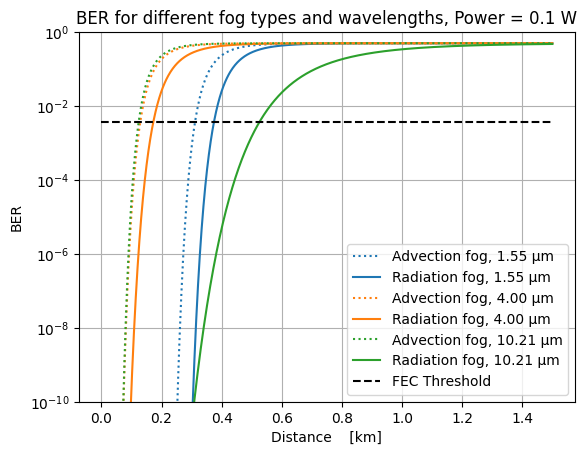

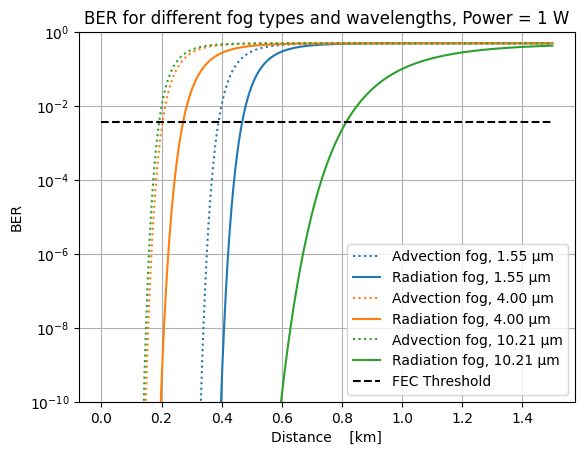

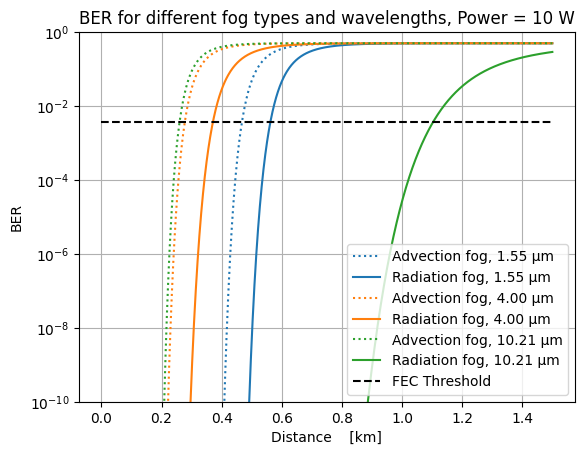

In [11]:
for i, power in enumerate(power_input):
    plt.figure(i)

    for wav_index in wav_FSO_index:
        line = plt.plot(distance,BER_adv[i][wav_index], label=f"Advection fog, {wavelengths[wav_index]:.2f} µm",  linestyle='dotted')

        plt.plot(distance,BER_rad[i][wav_index], label=f"Radiation fog, {wavelengths[wav_index]:.2f} µm", color=line[0].get_color())

    plt.hlines(FEC_thres, 0, 1.5, colors='black', linestyles='dashed', label="FEC Threshold")
    plt.legend()
    plt.grid()
    plt.yscale("log")
    plt.ylim(1e-10,1)
    plt.xlabel("Distance    [km]")
    plt.ylabel("BER")
    plt.title(f"BER for different fog types and wavelengths, Power = {power} W")

    plt.savefig(rf"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\BER_{power}W.svg")
    plt.savefig(rf"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\BER_{power}W.pdf")



In [12]:
dist_cross_FEC_rad = [[0 for _ in range(len(wavelengths))] for _ in range(len(power_input))]

dist_cross_FEC_adv = [[0 for _ in range(len(wavelengths))] for _ in range(len(power_input))]

indices_rad_cross =  [[0 for _ in range(len(wavelengths))] for _ in range(len(power_input))]

indices_adv_cross =  [[0 for _ in range(len(wavelengths))] for _ in range(len(power_input))]

for i, power in enumerate(power_input):
    for j in range(len(wavelengths)):
    
        index_rad = np.min(np.where(BER_rad[i][j] >= FEC_thres))

        indices_rad_cross[i][j] = index_rad
        
        

        index_adv = np.min(np.where(BER_adv[i][j] >= FEC_thres))

        indices_adv_cross[i][j] = index_adv


        dist_cross_FEC_rad[i][j] = distance[index_rad]
        dist_cross_FEC_adv[i][j] = distance[index_adv]



Rad fog, Power 0.1 W, 1.55 µm, cross at: 0.375 km
Rad fog, Power 0.1 W, 4.00 µm, cross at: 0.174 km
Rad fog, Power 0.1 W, 10.21 µm, cross at: 0.527 km
Adv fog, Power 0.1 W, 1.55 µm, cross at: 0.312 km
Adv fog, Power 0.1 W, 4.00 µm, cross at: 0.131 km
Adv fog, Power 0.1 W, 10.21 µm, cross at: 0.125 km
Rad fog, Power 1 W, 1.55 µm, cross at: 0.468 km
Rad fog, Power 1 W, 4.00 µm, cross at: 0.273 km
Rad fog, Power 1 W, 10.21 µm, cross at: 0.815 km
Adv fog, Power 1 W, 1.55 µm, cross at: 0.390 km
Adv fog, Power 1 W, 4.00 µm, cross at: 0.204 km
Adv fog, Power 1 W, 10.21 µm, cross at: 0.192 km
Rad fog, Power 10 W, 1.55 µm, cross at: 0.563 km
Rad fog, Power 10 W, 4.00 µm, cross at: 0.372 km
Rad fog, Power 10 W, 10.21 µm, cross at: 1.105 km
Adv fog, Power 10 W, 1.55 µm, cross at: 0.468 km
Adv fog, Power 10 W, 4.00 µm, cross at: 0.278 km
Adv fog, Power 10 W, 10.21 µm, cross at: 0.261 km


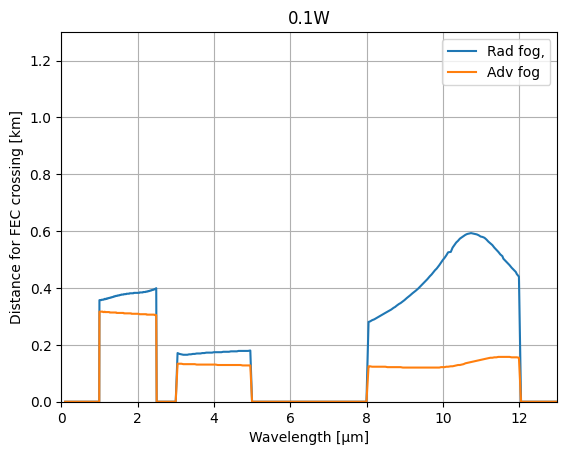

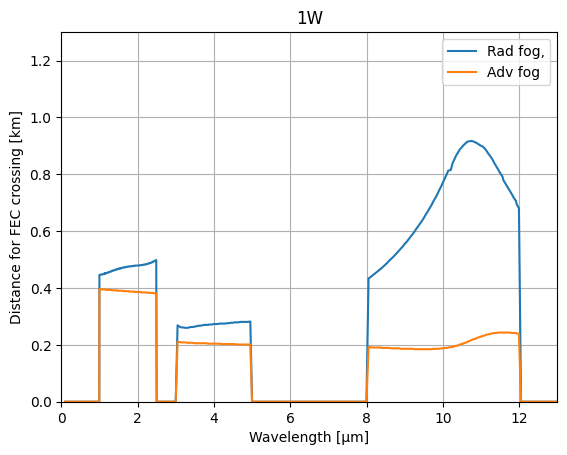

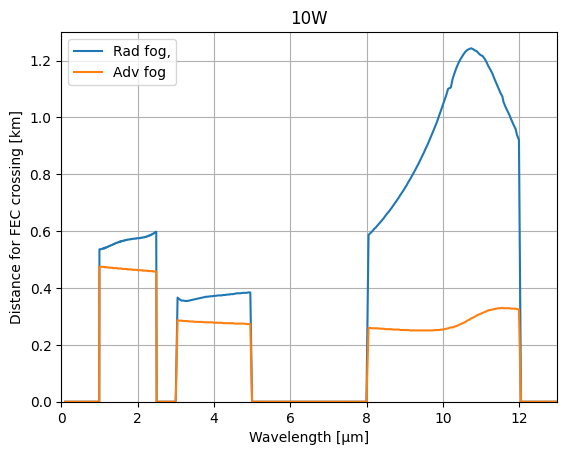

In [13]:
for i, power in enumerate(power_input):
    plt.figure()
    plt.plot(wavelengths,dist_cross_FEC_rad[i],label='Rad fog,')
    plt.plot(wavelengths,dist_cross_FEC_adv[i],label='Adv fog')
    plt.title(f'{power}W')
    plt.ylim([0.0,0.7+2*0.3])
    plt.xlim([0.,13])
    plt.ylabel('Distance for FEC crossing [km]')
    plt.xlabel('Wavelength [µm]')
    plt.grid()
    plt.legend()
    # max_index = np.where(dist_cross_FEC_rad[i] == np.max(dist_cross_FEC_rad[i]))[0][0]
    # plt.xticks(list(plt.xticks()[0]) + [wavelengths[max_index]])

    plt.savefig(rf"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\dist_FEC_cross_{power}W.pdf")

    plt.savefig(rf"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Mid-IR\Grillot fog figures replicated\dist_FEC_cross_{power}W.svg")

    for wav_index in wav_FSO_index:
        print(f'Rad fog, Power {power} W, {wavelengths[wav_index]:.2f} µm, cross at: {dist_cross_FEC_rad[i][wav_index]:.3f} km' )

    for wav_index in wav_FSO_index:
        print(f'Adv fog, Power {power} W, {wavelengths[wav_index]:.2f} µm, cross at: {dist_cross_FEC_adv[i][wav_index]:.3f} km' )
